# Introduction

## Judul

Analisis Prediktif dan Strategi Komersial dalam Meningkatkan Upgrade Kamar Berbayar di Hotel Pasca Peak Season

## Latar Belakang

Dalam industri perhotelan, upgrade kamar merupakan salah satu strategi potensial untuk meningkatkan pendapatan tambahan (ancillary revenue), terutama setelah periode peak season saat tingkat okupansi mulai menurun. Namun, praktik upgrade yang sering dilakukan secara gratis atau tanpa segmentasi yang jelas berisiko menurunkan nilai kamar dan melewatkan peluang bisnis yang sebenarnya bisa dimonetisasi.

Melihat adanya variasi perilaku tamu—seperti waktu pemesanan, durasi menginap, saluran reservasi, hingga jenis tamu—terdapat potensi untuk memanfaatkan data historis guna memprediksi kemungkinan upgrade kamar secara lebih terukur dan strategis. Dengan pendekatan analisis prediktif dan pemetaan karakteristik tamu, hotel dapat mengidentifikasi siapa saja yang memiliki kecenderungan untuk melakukan upgrade, dan merancang strategi komersial yang mendorong terjadinya upgrade berbayar, bukan sekadar layanan tambahan tanpa nilai ekonomi.

Penelitian ini diarahkan untuk membangun model prediksi kemungkinan upgrade kamar, serta menyusun rekomendasi bisnis berbasis data guna membantu hotel meningkatkan pendapatan secara efektif di masa setelah puncak kunjungan (post-peak season).

# Preparation

In [ ]:
# import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [ ]:
# connect gdrive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# open dataset
df = pd.read_csv('/content/drive/MyDrive/Study Case Interview user 2/train.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID
0,"Crystal Cove, Barbados Barbados",0,8,2019,January,2,10,0,4,2,0.0,0,BB,ITA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,314.0,NaN,0,Transient,38.40,0,0,Check-Out,2019-01-14,1
1,"Greensboro Courtyard Greensboro, NC",1,524,2018,December,51,15,0,2,2,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,1.0,NaN,0,Transient,62.80,0,0,Canceled,2017-10-21,2
2,"The Westin Peachtree Plaza, Atlanta Atlanta, GA",1,175,2019,May,20,19,1,2,2,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,12.0,NaN,0,Transient,110.00,0,0,Canceled,2018-11-25,3
3,Courtyard by Marriott Aberdeen Airport Aberdee...,0,0,2018,October,43,17,1,0,1,0.0,0,BB,NaN,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,200.0,0,Transient,45.00,0,0,Check-Out,2018-10-18,4
4,"W New York – Union Square New York, NY",1,33,2017,September,39,26,2,3,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,16.0,NaN,0,Transient,57.92,0,1,Canceled,2017-08-24,5


# Data Understanding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83293 non-null  object 
 1   is_canceled                     83293 non-null  int64  
 2   lead_time                       83293 non-null  int64  
 3   arrival_date_year               83293 non-null  int64  
 4   arrival_date_month              83293 non-null  object 
 5   arrival_date_week_number        83293 non-null  int64  
 6   arrival_date_day_of_month       83293 non-null  int64  
 7   stays_in_weekend_nights         83293 non-null  int64  
 8   stays_in_week_nights            83293 non-null  int64  
 9   adults                          83293 non-null  int64  
 10  children                        83290 non-null  float64
 11  babies                          83293 non-null  int64  
 12  meal                            

ada 83.293 baris, dengan 33 feature


| No | Nama Kolom                       | Deskripsi Kemungkinan                                                          |
| -- | -------------------------------- | ------------------------------------------------------------------------------ |
| 1  | `hotel`                          | Nama hotel tempat reservasi (City Hotel atau Resort Hotel)                     |
| 2  | `is_canceled`                    | Status apakah pemesanan dibatalkan (1: ya, 0: tidak)                           |
| 3  | `lead_time`                      | Jumlah hari antara pemesanan dan tanggal kedatangan                            |
| 4  | `arrival_date_year`              | Tahun kedatangan                                                               |
| 5  | `arrival_date_month`             | Bulan kedatangan (nama bulan, misal: Januari)                                  |
| 6  | `arrival_date_week_number`       | Nomor minggu dalam tahun saat kedatangan                                       |
| 7  | `arrival_date_day_of_month`      | Tanggal kedatangan (dalam sebulan)                                             |
| 8  | `stays_in_weekend_nights`        | Lama tinggal di akhir pekan (jumat-sabtu)                                      |
| 9  | `stays_in_week_nights`           | Lama tinggal di hari kerja (minggu-kamis)                                      |
| 10 | `adults`                         | Jumlah dewasa dalam pemesanan                                                  |
| 11 | `children`                       | Jumlah anak-anak dalam pemesanan                                               |
| 12 | `babies`                         | Jumlah bayi dalam pemesanan                                                    |
| 13 | `meal`                           | Jenis paket makan yang dipesan (BB, HB, FB, SC, dll.)                          |
| 14 | `country`                        | Negara asal tamu                                                               |
| 15 | `market_segment`                 | Sumber pasar (misalnya: Online TA, Corporate, Direct)                          |
| 16 | `distribution_channel`           | Saluran distribusi (Online, Travel Agent, Corporate, dll.)                     |
| 17 | `is_repeated_guest`              | Apakah tamu adalah pelanggan tetap (1: ya, 0: tidak)                           |
| 18 | `previous_cancellations`         | Jumlah pembatalan yang pernah dilakukan sebelumnya oleh tamu tersebut          |
| 19 | `previous_bookings_not_canceled` | Jumlah reservasi sebelumnya yang tidak dibatalkan                              |
| 20 | `reserved_room_type`             | Tipe kamar yang dipesan awalnya                                                |
| 21 | `assigned_room_type`             | Tipe kamar yang diberikan saat check-in                                        |
| 22 | `booking_changes`                | Jumlah perubahan yang dilakukan pada reservasi                                 |
| 23 | `deposit_type`                   | Jenis deposit (No Deposit, Non Refund, Refundable)                             |
| 24 | `agent`                          | ID agen perjalanan yang melakukan reservasi                                    |
| 25 | `company`                        | ID perusahaan jika reservasi dilakukan oleh perusahaan                         |
| 26 | `days_in_waiting_list`           | Lama hari dalam daftar tunggu sebelum konfirmasi                               |
| 27 | `customer_type`                  | Jenis pelanggan (Transient, Contract, Group, dll.)                             |
| 28 | `adr`                            | **Average Daily Rate**, pendapatan per kamar per malam                         |
| 29 | `required_car_parking_spaces`    | Jumlah tempat parkir mobil yang diminta                                        |
| 30 | `total_of_special_requests`      | Jumlah permintaan khusus (misal: twin bed, lantai atas, dll.)                  |
| 31 | `reservation_status`             | Status reservasi (Check-Out, Canceled, No-Show)                                |
| 32 | `reservation_status_date`        | Tanggal saat status reservasi terakhir diperbarui                              |
| 33 | `booking_id`                     | ID unik untuk setiap pemesanan (mungkin digunakan untuk identifikasi internal) |


In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,bookingID
count,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83290.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,71889.000000,4734.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000
mean,0.369503,103.914230,2018.156808,27.164023,15.786116,0.930390,2.503812,1.854466,0.103614,0.008032,0.030243,0.086994,0.141765,0.223068,86.867282,190.003802,2.352238,101.724373,0.061818,0.571945,41647.000000
std,0.482673,106.874124,0.706656,13.623752,8.775931,1.004196,1.924511,0.606139,0.398821,0.100641,0.171255,0.862988,1.554390,0.656237,110.875605,131.969152,17.820652,48.082552,0.245027,0.793742,24044.762323
min,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,18.000000,2018.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.530000,0.000000,0.000000,20824.000000
50%,0.000000,69.000000,2018.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,183.000000,0.000000,94.500000,0.000000,0.000000,41647.000000
75%,1.000000,160.000000,2019.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000,62470.000000
max,1.000000,737.000000,2019.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,70.000000,21.000000,535.000000,543.000000,391.000000,508.000000,8.000000,5.000000,83293.000000


In [ ]:
# summary setiap coloumn

for col in df.columns:
    print(f"Summary of column: {col}")
    print(df[col].describe())
    print("-" * 50)

Summary of column: hotel
count                                                 83293
unique                                                   64
top       Renaissance New York Times Square Hotel New Yo...
freq                                                   1373
Name: hotel, dtype: object
--------------------------------------------------
Summary of column: is_canceled
count    83293.000000
mean         0.369503
std          0.482673
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: is_canceled, dtype: float64
--------------------------------------------------
Summary of column: lead_time
count    83293.000000
mean       103.914230
std        106.874124
min          0.000000
25%         18.000000
50%         69.000000
75%        160.000000
max        737.000000
Name: lead_time, dtype: float64
--------------------------------------------------
Summary of column: arrival_date_year
count    83293.000000
mean      2018.156

In [ ]:
# cek data duplicate

df.duplicated().sum()

np.int64(0)

In [ ]:
# cek missing value

df.isna().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
# melihat nilai unik setiap kolom

for col in df.columns:
    print(f"\n--- Kolom: {col} ---")
    print(f"Jumlah unique: {df[col].nunique()}")
    print(f"Daftar unique values:\n{df[col].unique()}")


--- Kolom: hotel ---
Jumlah unique: 64
Daftar unique values:
['Crystal Cove, Barbados Barbados' 'Greensboro Courtyard Greensboro, NC'
 'The Westin Peachtree Plaza, Atlanta Atlanta, GA '
 'Courtyard by Marriott Aberdeen Airport Aberdeen, United Kingdom'
 'W New York – Union Square New York, NY'
 'Hotel Maria Cristina, San Sebastian San Sebastian, Spain'
 'W New York – Times Square New York, NY'
 'The Ritz-Carlton, Tokyo Tokyo, Japan'
 'Marriott Puerto Vallarta Resort & Spa Puerto Vallarta, Mexico'
 'Las Vegas Marriott Las Vegas, NV '
 'Heidelberg Marriott Hotel Heidelberg, Germany'
 'Sheraton Grand Rio Hotel & Resort Rio de Janeiro, Brazil'
 'Renaissance Hamburg Hotel Hamburg, Germany'
 'The Ritz-Carlton, Berlin Berlin, Germany'
 'Sheraton Lima Hotel & Convention Center Lima, Peru'
 'Courtyard Las Vegas Convention Center Las Vegas, NV '
 'Newark Liberty International Airport Courtyard Newark, NJ'
 'Indianapolis Airport Courtyard Indianapolis, IN'
 'Treasure Beach, Barbados Barbados'
 '

In [ ]:
# summary nilai unik tersebut

summary = []

for col in df.columns:
    summary.append({
        'Kolom': col,
        'Jumlah Unique': df[col].nunique()
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

                             Kolom  Jumlah Unique
0                            hotel             64
1                      is_canceled              2
2                        lead_time            477
3                arrival_date_year              3
4               arrival_date_month             12
5         arrival_date_week_number             53
6        arrival_date_day_of_month             31
7          stays_in_weekend_nights             17
8             stays_in_week_nights             34
9                           adults             14
10                        children              5
11                          babies              5
12                            meal              5
13                         country            165
14                  market_segment              8
15            distribution_channel              5
16               is_repeated_guest              2
17          previous_cancellations             14
18  previous_bookings_not_canceled             65


# Data Cleaning

In [ ]:
df_copy = df.copy()

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83293 non-null  object 
 1   is_canceled                     83293 non-null  int64  
 2   lead_time                       83293 non-null  int64  
 3   arrival_date_year               83293 non-null  int64  
 4   arrival_date_month              83293 non-null  object 
 5   arrival_date_week_number        83293 non-null  int64  
 6   arrival_date_day_of_month       83293 non-null  int64  
 7   stays_in_weekend_nights         83293 non-null  int64  
 8   stays_in_week_nights            83293 non-null  int64  
 9   adults                          83293 non-null  int64  
 10  children                        83290 non-null  float64
 11  babies                          83293 non-null  int64  
 12  meal                            

## Duplicate Handling

In [ ]:
# check duplicate

df_copy.duplicated().sum()

np.int64(0)

Tidak ada data yang duplicate

## **Nan, Missing value, and Weird value handling**

In [ ]:
# melihat nilai yang tidak sesuai pada tiap kolom

weird_values = ['-1', -1, 'unknown', 'Unknown', 'Undefined', 'nan', np.nan]

for col in df_copy.columns:
    uniques = df_copy[col].astype(str).unique()
    suspicious = [val for val in uniques if val in map(str, weird_values)]
    if suspicious:
        print(f"Kolom: {col} -> Nilai mencurigakan: {suspicious}")

Kolom: children -> Nilai mencurigakan: ['nan']
Kolom: meal -> Nilai mencurigakan: ['Undefined']
Kolom: country -> Nilai mencurigakan: ['nan']
Kolom: market_segment -> Nilai mencurigakan: ['Undefined']
Kolom: distribution_channel -> Nilai mencurigakan: ['Undefined']
Kolom: agent -> Nilai mencurigakan: ['nan']
Kolom: company -> Nilai mencurigakan: ['nan']


In [ ]:
# jumlah nan dalam kolom children

df_copy['children'].isna().sum()

np.int64(3)

In [ ]:
# drop

df_copy.dropna(subset=['children'], inplace=True)

In [ ]:
# presentase undefined dikolom meal

df_copy['meal'].value_counts(normalize=True)

,proportion
meal,
BB,0.773454
HB,0.121239
SC,0.088858
Undefined,0.009941
FB,0.006507


karena jumlah undefinednya 9% kita akan lakukan imputasi menggunakan modus

In [ ]:
# imputasi nilai undefined menjadi modusnya

# Hitung modus kolom (tidak termasuk 'undefined')
modus_meal = df_copy[df_copy['meal'] != 'Undefined']['meal'].mode()[0]

# Ganti nilai 'undefined' dengan modus
df_copy['meal'] = df_copy['meal'].replace('Undefined', modus_meal)

# Cek hasil
print(f"Modus kolom '{'meal'}': {modus_meal}")
print(df_copy['meal'].value_counts())

Modus kolom 'meal': BB
meal
BB    65249
HB    10098
SC     7401
FB      542
Name: count, dtype: int64


Nilai undefined pada kolom meal telah dirubah menjadi nilai modusnya yaitu BB

In [ ]:
# persentase nilai nan pada country

df_copy['country'].isna().sum() / len(df_copy) * 100

np.float64(0.4154160163284908)

persentase nilai nan pada country cukup besar di 41.5%. kita coba tinggalkan dulu bisa jadi kolom country ini bisa di drop karena berdasarkan nama hotel juga bisa dilakukan penarikan country tersendiri.

In [ ]:
# presentase nilai undefined pada market_segment

df_copy['market_segment'].value_counts(normalize=True)

,proportion
market_segment,
Online TA,0.473574
Offline TA/TO,0.203170
Groups,0.165578
Direct,0.104947
Corporate,0.044495
Complementary,0.006291
Aviation,0.001945


In [ ]:
df_copy['market_segment'].unique()

array(['Online TA', 'Groups', 'Corporate', 'Offline TA/TO', 'Direct',
       'Complementary', 'Aviation'], dtype=object)

sudah tidak ditemukan "undefined" karena jumlah undefined hanya satu dan terdrop bersamaan dengan children "nan" sebelumnya

In [ ]:
# persentase distribution_channel

df_copy['distribution_channel'].value_counts(normalize=True)

,proportion
distribution_channel,
TA/TO,0.820843
Direct,0.121935
Corporate,0.055613
GDS,0.001597
Undefined,0.000012


jumlah undifined nya sangat jauh di 0.012% dari data sehingga bisa di drop saja baris tersebut

In [ ]:
# drop undefined pada distribution_channel

df_copy = df_copy[df_copy['distribution_channel'] != 'Undefined']
df_copy['distribution_channel'].unique()

array(['TA/TO', 'Corporate', 'Direct', 'GDS'], dtype=object)

In [ ]:
# persentase nan pada agent

df_copy['agent'].isna().sum() / len(df_copy) * 100

np.float64(13.689682911308818)

karena persentase nan masih terlalu tinggi 13.6% dan keragaman 320 nilai unik, maka tidak mungkin mengganti hal ini dengan modus yang akan menyebabkan ketidak seimbangan data, dan jika di drop akan mengurangi keragaman dari data tersebut sebanyak 11.402 baris. jadi solusi akan dilakukan penggantian/imputasi nan menjadi "No_Agent"

In [ ]:
# Ganti nilai NaN dengan label baru
df_copy['agent'] = df_copy['agent'].fillna('No_Agent')

# Pastikan kolom bertipe string untuk label seperti 'No_Agent'
df_copy['agent'] = df_copy['agent'].astype(str)

# Cek hasil
print(df_copy['agent'].value_counts().head())

agent
9.0         22304
No_Agent    11402
240.0        9667
1.0          4943
14.0         2528
Name: count, dtype: int64


/tmp/ipython-input-25-1419455029.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy['agent'] = df_copy['agent'].fillna('No_Agent')
/tmp/ipython-input-25-1419455029.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy['agent'] = df_copy['agent'].astype(str)


In [ ]:
# hitung presentasi nilai nan pada company

df_copy['company'].isna().sum() / len(df_copy) * 100

np.float64(94.31617620574146)

94% data di kolom company adalah nan, maka kita akan lalukan drop kolom tersebut

In [ ]:
# drop kolom company

df_copy.drop(columns=['company'], inplace=True)

/tmp/ipython-input-27-1217020479.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy.drop(columns=['company'], inplace=True)


## Change data type

In [ ]:
df_type =df_copy.copy()

In [ ]:
# pada kolom children ganti type float menjadi int

df_type['children'] = df_type['children'].astype(int)

In [ ]:
# ganti type kolom arrival_date_year dan day menjadi int

df_type['arrival_date_year'] = df_type['arrival_date_year'].astype(int)
df_type['arrival_date_day_of_month'] = df_type['arrival_date_day_of_month'].astype(int)

# kolom month ganti menjadi int

month_mapping = {
    'January': 1, 'February': 2, 'March': 3,
    'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9,
    'October': 10, 'November': 11, 'December': 12
}

df_type['arrival_date_month'] = df_type['arrival_date_month'].replace(month_mapping)

# gabungkan

df_type['arrival_date'] = pd.to_datetime(
    df_type['arrival_date_year'].astype(str) + '-' +
    df_type['arrival_date_month'].astype(str).str.zfill(2) + '-' +
    df_type['arrival_date_day_of_month'].astype(str).str.zfill(2),
    format='%Y-%m-%d',
     errors='coerce'
)

/tmp/ipython-input-30-3031163857.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_type['arrival_date_month'] = df_type['arrival_date_month'].replace(month_mapping)


In [ ]:
# ganti reservation_status_date menjadi datetime

df_type['reservation_status_date'] = pd.to_datetime(df_type['reservation_status_date'])

## Others

In [ ]:
df_clean = df_type.copy()

In [ ]:
df_clean['hotel'].unique()

array(['Crystal Cove, Barbados Barbados',
       'Greensboro Courtyard Greensboro, NC',
       'The Westin Peachtree Plaza, Atlanta Atlanta, GA ',
       'Courtyard by Marriott Aberdeen Airport Aberdeen, United Kingdom',
       'W New York – Union Square New York, NY',
       'Hotel Maria Cristina, San Sebastian San Sebastian, Spain',
       'W New York – Times Square New York, NY',
       'The Ritz-Carlton, Tokyo Tokyo, Japan',
       'Marriott Puerto Vallarta Resort & Spa Puerto Vallarta, Mexico',
       'Las Vegas Marriott Las Vegas, NV ',
       'Heidelberg Marriott Hotel Heidelberg, Germany',
       'Sheraton Grand Rio Hotel & Resort Rio de Janeiro, Brazil',
       'Renaissance Hamburg Hotel Hamburg, Germany',
       'The Ritz-Carlton, Berlin Berlin, Germany',
       'Sheraton Lima Hotel & Convention Center Lima, Peru',
       'Courtyard Las Vegas Convention Center Las Vegas, NV ',
       'Newark Liberty International Airport Courtyard Newark, NJ',
       'Indianapolis Airport Cou

In [ ]:
# Pisahkan hanya pada koma terakhir
df_clean[['hotel_name', 'city']] = df_clean['hotel'].str.rsplit(',', n=1, expand=True)

# Hilangkan spasi ekstra
df_clean['hotel_name'] = df_clean['hotel_name'].str.strip()
df_clean['city'] = df_clean['city'].str.strip()

In [ ]:
df_clean['city'].unique()

array(['Barbados Barbados', 'NC', 'GA', 'United Kingdom', 'NY', 'Spain',
       'Japan', 'Mexico', 'NV', 'Germany', 'Brazil', 'Peru', 'NJ', 'IN',
       'South Africa', 'IL', 'LA', 'NM', 'Italy', 'TX', 'CA', 'FL', 'KY',
       'MD', 'France', 'MO', 'WA', 'IA', 'Dominican Republic'],
      dtype=object)

In [ ]:
df_clean.groupby('hotel')['country'].nunique().sort_values(ascending=False)

,country
hotel,
"W London – Leicester Square London, United Kingdom",68
"Courtyard by Marriott Aberdeen Airport Aberdeen, United Kingdom",65
"Sheraton Lima Hotel & Convention Center Lima, Peru",64
"Crystal Cove, Barbados Barbados",63
"The St. Regis Osaka Osaka, Japan",63
...,...
"Courtyard by Marriott Paris Gare de Lyon Paris, France",50
"African Pride Melrose Arch, Autograph Collection Johannesburg, South Africa",49
"Spokane Downtown at the Convention Center Courtyard Spokane, WA",48


Setelah dilakukan pengecekan dan diketahui bahwa untuk setiap hotel akan memiliki cabang di beberapa country, jadi kolom city dan hotel_name tidak jadi digunakan, kemudian untuk nilai "nan" pada kolom country akan di imputasikan dengan nilai baru "Unknown"

In [ ]:
# ganti nilai "nan" pada kolom country menjadi "Unknown"

df_clean['country'] = df_clean['country'].fillna('Unknown')

In [ ]:
df_clean.isna().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
# melihat arrival-date yang isna

df_clean[df_clean['arrival_date'].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID,arrival_date,hotel_name,city
1565,"The Westin Peachtree Plaza, Atlanta Atlanta, GA",1,117,2018,2,10,29,1,2,2,0,0,BB,PRT,Offline TA/TO,TA/TO,0,1,0,A,A,0,Non Refund,19.0,44,Transient,75.00,0,0,Canceled,2017-12-18,1566,NaT,"The Westin Peachtree Plaza, Atlanta Atlanta",GA
3069,"Colony Club, Barbados Barbados",0,117,2018,2,10,29,1,2,2,0,0,BB,IRN,Offline TA/TO,TA/TO,0,0,0,A,A,2,No Deposit,134.0,0,Transient-Party,86.33,0,0,Check-Out,2018-03-03,3070,NaT,Colony Club,Barbados Barbados
3081,Protea Hotel by Marriott O.R. Tambo Airport Jo...,1,138,2018,2,10,29,3,7,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0,Transient,40.50,0,1,Canceled,2017-12-31,3082,NaT,Protea Hotel by Marriott O.R. Tambo Airport Jo...,South Africa
3792,Sheraton Grand Rio Hotel & Resort Rio de Janei...,1,117,2018,2,10,29,1,2,2,0,0,BB,PRT,Offline TA/TO,TA/TO,0,1,0,A,A,0,Non Refund,19.0,44,Transient,75.00,0,0,Canceled,2017-12-18,3793,NaT,Sheraton Grand Rio Hotel & Resort Rio de Janeiro,Brazil
4488,Protea Hotel Fire & Ice! by Marriott Johannesb...,1,21,2018,2,10,29,1,3,1,0,0,BB,TUR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,0,Transient,102.05,0,0,Canceled,2018-02-26,4489,NaT,Protea Hotel Fire & Ice! by Marriott Johannesb...,South Africa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77857,"W Barcelona Barcelona, Spain",1,117,2018,2,10,29,1,2,2,0,0,BB,PRT,Offline TA/TO,TA/TO,0,1,0,A,A,0,Non Refund,19.0,44,Transient,75.00,0,0,Canceled,2017-12-18,77858,NaT,W Barcelona Barcelona,Spain
78926,"Mt. Laurel Courtyard Mt. Laurel, NJ",1,50,2018,2,10,29,1,0,2,0,0,SC,CN,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,0,Transient,76.50,0,0,Canceled,2018-02-25,78927,NaT,Mt. Laurel Courtyard Mt. Laurel,NJ
79306,"Anaheim Marriott Anaheim, CA",1,40,2018,2,10,29,1,4,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0,Transient,48.00,0,2,Canceled,2018-01-23,79307,NaT,Anaheim Marriott Anaheim,CA
81571,"Des Moines West/Clive Courtyard Clive, IA",1,117,2018,2,10,29,1,2,2,0,0,BB,PRT,Offline TA/TO,TA/TO,0,1,0,A,A,0,Non Refund,19.0,44,Transient,75.00,0,0,Canceled,2017-12-18,81572,NaT,Des Moines West/Clive Courtyard Clive,IA


ketahui ada baris data pada kolom arrival_date yang memiliki struktur tanggal yang salah yaitu 2018-02-29, ini bukan termasuk tahun kabisat, jadi akan dilakukan drop baris saja

In [ ]:
# drop baris "nan" di kolom arrival_date

df_clean.dropna(subset=['arrival_date'], inplace=True)

In [ ]:
df_clean.isna().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
# simpan data

df_clean.to_csv('data_hotel_clean.csv', index=False)

In [ ]:
# simpan ke googledrive

df_clean.to_csv('/content/drive/MyDrive/Simulasi/data_hotel_clean.csv', index=False)

# Feature Engineering

In [ ]:
df_eda = df_clean.copy()

Kapan terjadi lonjakan ADR ?

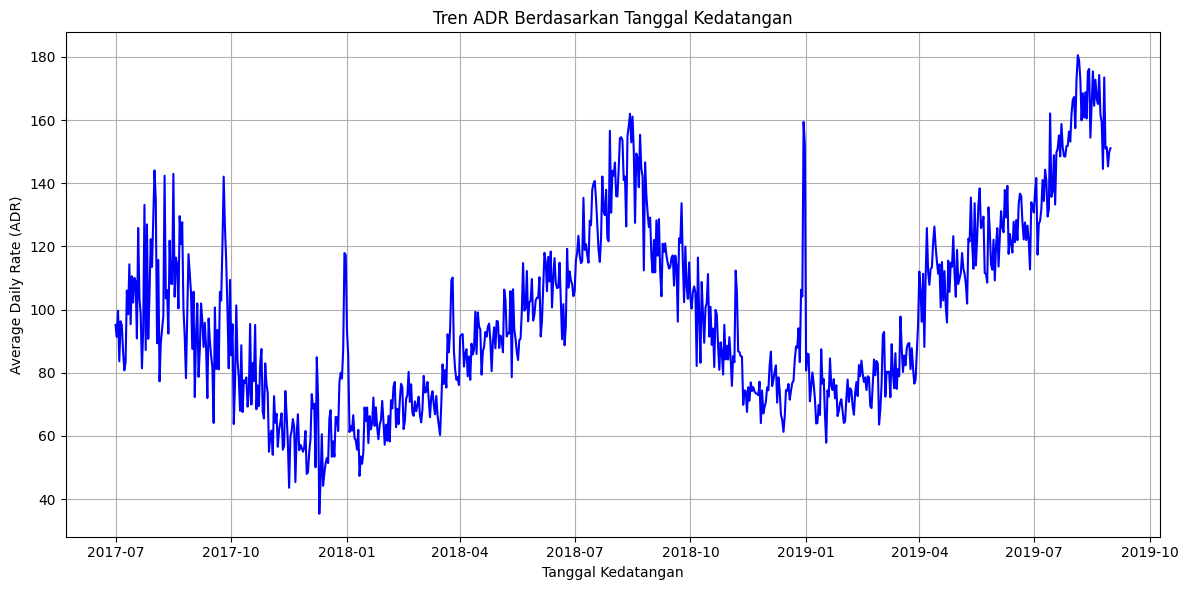

In [ ]:
# Hitung rata-rata ADR per tanggal kedatangan
adr_per_tanggal = df_eda.groupby('arrival_date')['adr'].mean().reset_index()

# Buat lineplot tren ADR
plt.figure(figsize=(12, 6))
plt.plot(adr_per_tanggal['arrival_date'], adr_per_tanggal['adr'], color='blue')
plt.title('Tren ADR Berdasarkan Tanggal Kedatangan')
plt.xlabel('Tanggal Kedatangan')
plt.ylabel('Average Daily Rate (ADR)')
plt.grid(True)
plt.tight_layout()
plt.show()

terdapat pola pada rata-rata adr pertahunnya seperti:

- terjadi penurunan setiap oktober hingga november
- dan lonjakan signifikan di bulan desember
- kemudian turun kembali di januari dan merangkak naik hingga bulan juli

berikutknya kita akan lakukan pengecekan terhadap pola lonjakan yang terjadi antara november hingga february tersebut

In [ ]:
# filter 2 rentang waktu setelah terjadi lonjakan, yaitu 2018-01-01 hingga 2018-07-31 dan 2019-01-01 hingga 2018-07-31

df_2018 = df_eda[(df_eda['arrival_date'] >= '2018-01-01') & (df_eda['arrival_date'] <= '2018-07-31')]
df_2019 = df_eda[(df_eda['arrival_date'] >= '2019-01-01') & (df_eda['arrival_date'] <= '2019-07-31')]

# Gabungkan kembali kedua DataFrame
df_filtered = pd.concat([df_2018, df_2019], ignore_index=True)

In [ ]:
# bentuk kolom baru terkait upgrade atau non-upgrade dari room jika reserved_room_type tidak sama dengan assigned_room_type

df_filtered['upgrade_status'] = df_filtered.apply(
    lambda row: 'Upgrade' if row['reserved_room_type'] != row['assigned_room_type'] else 'No Upgrade',
    axis=1
)

In [ ]:
# lihat presentase upgrade dan no upgrade

upgrade_counts = df_filtered['upgrade_status'].value_counts()
upgrade_percentages = (upgrade_counts / upgrade_counts.sum()) * 100

upgrade_percentages

,count
upgrade_status,
No Upgrade,88.410969
Upgrade,11.589031


terdapat perbedan presentase yang cukup significant sehingga menjadikan data tesebut imbalance, smote perlu dilakukan nanti saat pemodelan.

In [ ]:
df_filtered.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID,arrival_date,hotel_name,city,upgrade_status
0,"Hotel Maria Cristina, San Sebastian San Sebast...",1,395,2018,3,13,21,1,2,2,0,0,BB,PRT,Groups,TA/TO,0,1,0,A,A,0,Non Refund,1.0,0,Transient,62.80,0,0,Canceled,2017-08-10,6,2018-03-21,"Hotel Maria Cristina, San Sebastian San Sebastian",Spain,No Upgrade
1,"The Ritz-Carlton, Tokyo Tokyo, Japan",0,52,2018,7,29,12,0,2,3,0,0,BB,DNK,Online TA,TA/TO,0,0,0,D,E,1,No Deposit,9.0,0,Transient,137.70,0,1,Check-Out,2018-07-14,8,2018-07-12,"The Ritz-Carlton, Tokyo Tokyo",Japan,Upgrade
2,"Las Vegas Marriott Las Vegas, NV",1,167,2018,7,31,29,0,2,2,0,0,SC,IRL,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,0,Transient,94.50,0,0,Canceled,2018-07-24,10,2018-07-29,Las Vegas Marriott Las Vegas,NV,No Upgrade
3,Sheraton Grand Rio Hotel & Resort Rio de Janei...,1,101,2018,6,27,27,1,5,1,0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,No_Agent,0,Transient,140.00,0,0,Canceled,2018-05-06,13,2018-06-27,Sheraton Grand Rio Hotel & Resort Rio de Janeiro,Brazil,No Upgrade
4,"Renaissance Hamburg Hotel Hamburg, Germany",0,83,2018,4,17,20,2,5,2,0,0,BB,DEU,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,27.0,0,Transient,80.75,0,0,Check-Out,2018-04-27,14,2018-04-20,Renaissance Hamburg Hotel Hamburg,Germany,No Upgrade


In [ ]:
df_filtered['distribution_channel'].value_counts()*100/len(df_filtered)

,count
distribution_channel,
TA/TO,82.108796
Direct,12.230506
Corporate,5.473778
GDS,0.186920


In [ ]:

# Fungsi baru untuk mengkategorikan lead_time
def kategorikan_booking(lead_time):
    if 0 <= lead_time <= 1:
        return 'last_minute_booking'
    elif 2 <= lead_time <= 30:
        return 'normal_booking'
    else:
        return 'early_booking'

# Terapkan ke df_lonjakan dan df_nonlonjakan
df_filtered['booking_category'] = df_filtered['lead_time'].apply(kategorikan_booking)

In [ ]:
# fungsi untuk kategory jumlah pengunjung
df_filtered['total_pax'] = df_filtered['adults'] + df_filtered['children'] + df_filtered['babies']

# Fungsi segmentasi jumlah pax
def classify_pax_segment(row):
    total = row['total_pax']
    adults = row['adults']

    # Kasus anak-anak tanpa pendamping dewasa
    if adults == 0 and (row['children'] > 0 or row['babies'] > 0):
        return 'Unaccompanied Children'

    # Segmentasi umum
    if total <= 2:
        return 'Solo/Couple'
    elif total <= 5:
        return 'Family'
    elif total <= 8:
        return 'Big Family'
    else:
        return 'Group'

# Terapkan fungsi ke dataframe
df_filtered['pax_segment'] = df_filtered.apply(classify_pax_segment, axis=1)

In [ ]:
df_filtered.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID,arrival_date,hotel_name,city,upgrade_status,booking_category,total_pax,pax_segment
0,"Hotel Maria Cristina, San Sebastian San Sebast...",1,395,2018,3,13,21,1,2,2,0,0,BB,PRT,Groups,TA/TO,0,1,0,A,A,0,Non Refund,1.0,0,Transient,62.80,0,0,Canceled,2017-08-10,6,2018-03-21,"Hotel Maria Cristina, San Sebastian San Sebastian",Spain,No Upgrade,early_booking,2,Solo/Couple
1,"The Ritz-Carlton, Tokyo Tokyo, Japan",0,52,2018,7,29,12,0,2,3,0,0,BB,DNK,Online TA,TA/TO,0,0,0,D,E,1,No Deposit,9.0,0,Transient,137.70,0,1,Check-Out,2018-07-14,8,2018-07-12,"The Ritz-Carlton, Tokyo Tokyo",Japan,Upgrade,early_booking,3,Family
2,"Las Vegas Marriott Las Vegas, NV",1,167,2018,7,31,29,0,2,2,0,0,SC,IRL,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,0,Transient,94.50,0,0,Canceled,2018-07-24,10,2018-07-29,Las Vegas Marriott Las Vegas,NV,No Upgrade,early_booking,2,Solo/Couple
3,Sheraton Grand Rio Hotel & Resort Rio de Janei...,1,101,2018,6,27,27,1,5,1,0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,No_Agent,0,Transient,140.00,0,0,Canceled,2018-05-06,13,2018-06-27,Sheraton Grand Rio Hotel & Resort Rio de Janeiro,Brazil,No Upgrade,early_booking,1,Solo/Couple
4,"Renaissance Hamburg Hotel Hamburg, Germany",0,83,2018,4,17,20,2,5,2,0,0,BB,DEU,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,27.0,0,Transient,80.75,0,0,Check-Out,2018-04-27,14,2018-04-20,Renaissance Hamburg Hotel Hamburg,Germany,No Upgrade,early_booking,2,Solo/Couple


In [ ]:
# simpan hasil feature engginering di gdrive

df_filtered.to_csv('/content/drive/MyDrive/Simulasi/data_hotel_feature_eng.csv', index=False)

# Exploratory Data Analytics (EDA)

## Bagaimana hubungan antara booking kategory dengan terjadinya upgrade kamar?

In [ ]:
# Hitung jumlah masing-masing booking_category dalam setiap status upgrade
booking_upgrade = df_filtered.groupby(['upgrade_status', 'booking_category']).size().reset_index(name='count')

# Hitung total per upgrade_status untuk dijadikan pembagi
total_per_status = booking_upgrade.groupby('upgrade_status')['count'].transform('sum')

# Hitung persentase
booking_upgrade['percentage'] = (booking_upgrade['count'] / total_per_status * 100).round(2)

# Pisahkan hasilnya berdasarkan status
no_upgrade = booking_upgrade[booking_upgrade['upgrade_status'] == 'No Upgrade']
upgrade = booking_upgrade[booking_upgrade['upgrade_status'] == 'Upgrade']

# Tampilkan
print("Distribusi Booking Category (No Upgrade):")
print(no_upgrade[['booking_category', 'percentage']])

print("\nDistribusi Booking Category (Upgrade):")
print(upgrade[['booking_category', 'percentage']])

Distribusi Booking Category (No Upgrade):
      booking_category  percentage
0        early_booking       69.87
1  last_minute_booking        6.90
2       normal_booking       23.23

Distribusi Booking Category (Upgrade):
      booking_category  percentage
3        early_booking       45.88
4  last_minute_booking       20.56
5       normal_booking       33.56


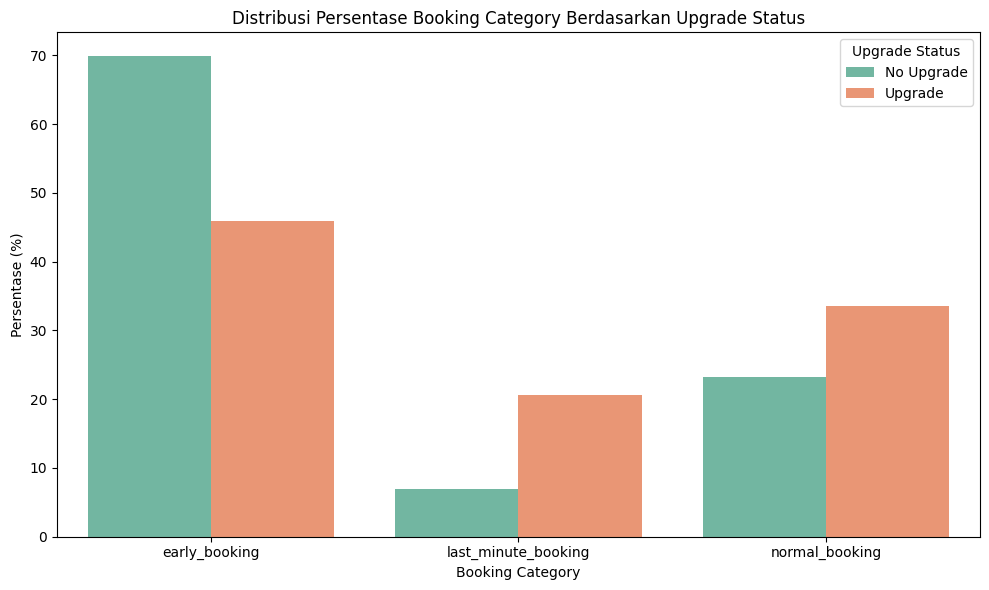

In [ ]:
# Gunakan data hasil sebelumnya: booking_upgrade (sudah ada kolom 'percentage')
plt.figure(figsize=(10,6))
sns.barplot(
    data=booking_upgrade,
    x='booking_category',
    y='percentage',
    hue='upgrade_status',
    palette='Set2'
)

plt.title('Distribusi Persentase Booking Category Berdasarkan Upgrade Status')
plt.ylabel('Persentase (%)')
plt.xlabel('Booking Category')
plt.legend(title='Upgrade Status')
plt.tight_layout()
plt.show()

Insight dari Distribusi Booking Category

Early Booking:

- Mendominasi pada No Upgrade (69.87%), tapi menurun drastis pada Upgrade (45.88%).

- Artinya, pemesanan lebih awal tidak menjamin mendapatkan upgrade, bahkan cenderung lebih jarang di-upgrade.

Last Minute Booking:

- Hanya 6.90% pada No Upgrade, tapi meningkat signifikan menjadi 20.56% pada Upgrade.

- Menunjukkan bahwa pemesanan mendadak lebih sering mendapatkan upgrade, kemungkinan karena hotel perlu mengisi kamar yang tersedia secara cepat.

Normal Booking:

- Persentase meningkat dari 23.23% (No Upgrade) menjadi 33.56% (Upgrade).

- Booking biasa memiliki peluang lebih baik untuk di-upgrade dibanding early booking, namun tidak sebesar last minute.

**Last-minute dan normal booking memiliki kemungkinan lebih tinggi untuk mendapat upgrade kamar dibanding early booking, yang justru lebih sering tidak di-upgrade.**

## Bagaimana hubungan antara segmentasi pengunjung dengan kemungkinan upgrade kamar?

In [ ]:
# Hitung jumlah masing-masing pax_segment dalam setiap status upgrade
segment_upgrade = df_filtered.groupby(['upgrade_status', 'pax_segment']).size().reset_index(name='count')

# Hitung total per upgrade_status
total_per_status = segment_upgrade.groupby('upgrade_status')['count'].transform('sum')

# Hitung persentase
segment_upgrade['percentage'] = (segment_upgrade['count'] / total_per_status * 100).round(2)

# Pisahkan berdasarkan status
no_upgrade = segment_upgrade[segment_upgrade['upgrade_status'] == 'No Upgrade']
upgrade = segment_upgrade[segment_upgrade['upgrade_status'] == 'Upgrade']

# Tampilkan
print("Distribusi Pax Segment (No Upgrade):")
print(no_upgrade[['pax_segment', 'percentage']])

print("\nDistribusi Pax Segment (Upgrade):")
print(upgrade[['pax_segment', 'percentage']])

Distribusi Pax Segment (No Upgrade):
              pax_segment  percentage
0                  Family       12.03
1                   Group        0.00
2             Solo/Couple       87.76
3  Unaccompanied Children        0.20

Distribusi Pax Segment (Upgrade):
              pax_segment  percentage
4                  Family       14.41
5             Solo/Couple       85.37
6  Unaccompanied Children        0.22


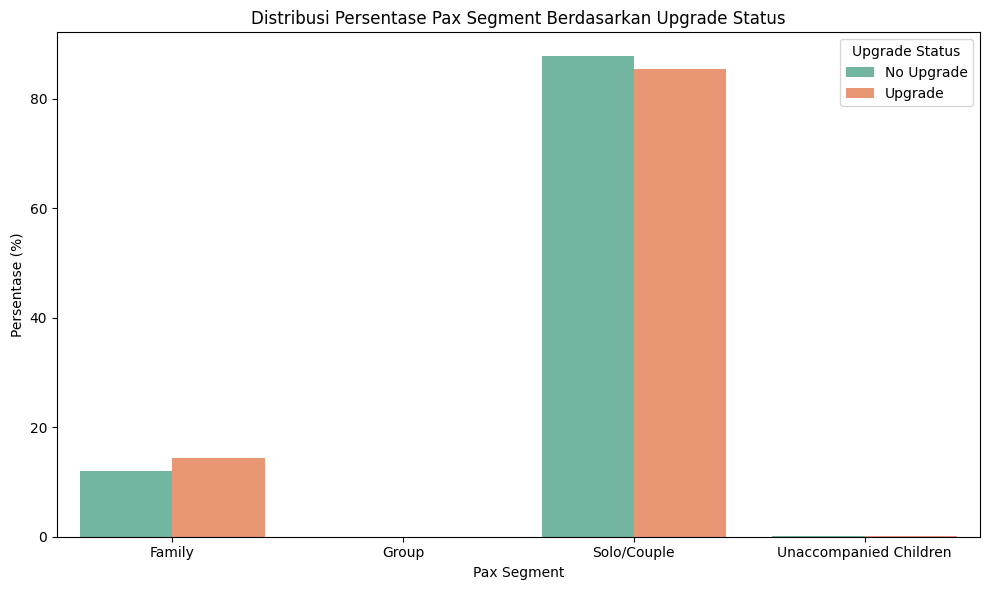

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=segment_upgrade,
    x='pax_segment',
    y='percentage',
    hue='upgrade_status',
    palette='Set2'
)

plt.title('Distribusi Persentase Pax Segment Berdasarkan Upgrade Status')
plt.ylabel('Persentase (%)')
plt.xlabel('Pax Segment')
plt.legend(title='Upgrade Status')
plt.tight_layout()
plt.show()

Insight dari Segmentasi Pengunjung terhadap Kemungkinan Upgrade


Solo/Couple:

- Mendominasi pada kedua kategori: 87.76% (No Upgrade) dan 85.37% (Upgrade).

- Meskipun mayoritas pengunjung adalah Solo/Couple, kemungkinan upgrade-nya tidak jauh berbeda dari distribusi awal — artinya segmen ini tidak terlalu spesial dalam peluang upgrade.

Family:

- Persentasenya meningkat dari 12.03% (No Upgrade) menjadi 14.41% (Upgrade).

- Ini menunjukkan bahwa segmen keluarga memiliki peluang upgrade yang sedikit lebih tinggi, kemungkinan karena kebutuhan kamar lebih besar atau penyesuaian kenyamanan.

Unaccompanied Children:

- Persentase tetap rendah di kedua kategori (0.20% vs 0.22%), artinya tidak signifikan dalam konteks upgrade.

Group:

- Tidak muncul sama sekali pada kategori Upgrade (0%), hanya ada di No Upgrade.

- Ini bisa menunjukkan bahwa kelompok (Group) hampir tidak pernah mendapatkan upgrade, mungkin karena kompleksitas permintaan kamar atau keterbatasan alokasi.

**Segmen keluarga memiliki kecenderungan sedikit lebih besar untuk mendapat upgrade kamar dibandingkan segmen lainnya. Sementara itu, grup cenderung tidak di-upgrade sama sekali, dan Solo/Couple tetap dominan secara jumlah, namun tidak menunjukkan hubungan kuat terhadap peningkatan peluang upgrade.**

## Jenis reservasi mana yang akan memiliki kemungkinan terbesar untuk melakukan upgrade kamar?

In [ ]:
# Hitung jumlah masing-masing distribution_channel dalam setiap status upgrade
channel_upgrade = df_filtered.groupby(['upgrade_status', 'distribution_channel']).size().reset_index(name='count')

# Hitung total per upgrade_status
total_per_status = channel_upgrade.groupby('upgrade_status')['count'].transform('sum')

# Hitung persentase
channel_upgrade['percentage'] = (channel_upgrade['count'] / total_per_status * 100).round(2)

# Pisahkan berdasarkan status
no_upgrade = channel_upgrade[channel_upgrade['upgrade_status'] == 'No Upgrade']
upgrade = channel_upgrade[channel_upgrade['upgrade_status'] == 'Upgrade']

# Tampilkan
print("Distribusi Distribution Channel (No Upgrade):")
print(no_upgrade[['distribution_channel', 'percentage']])

print("\nDistribusi Distribution Channel (Upgrade):")
print(upgrade[['distribution_channel', 'percentage']])

Distribusi Distribution Channel (No Upgrade):
  distribution_channel  percentage
0            Corporate        4.68
1               Direct       11.31
2                  GDS        0.20
3                TA/TO       83.80

Distribusi Distribution Channel (Upgrade):
  distribution_channel  percentage
4            Corporate       11.55
5               Direct       19.23
6                  GDS        0.05
7                TA/TO       69.17


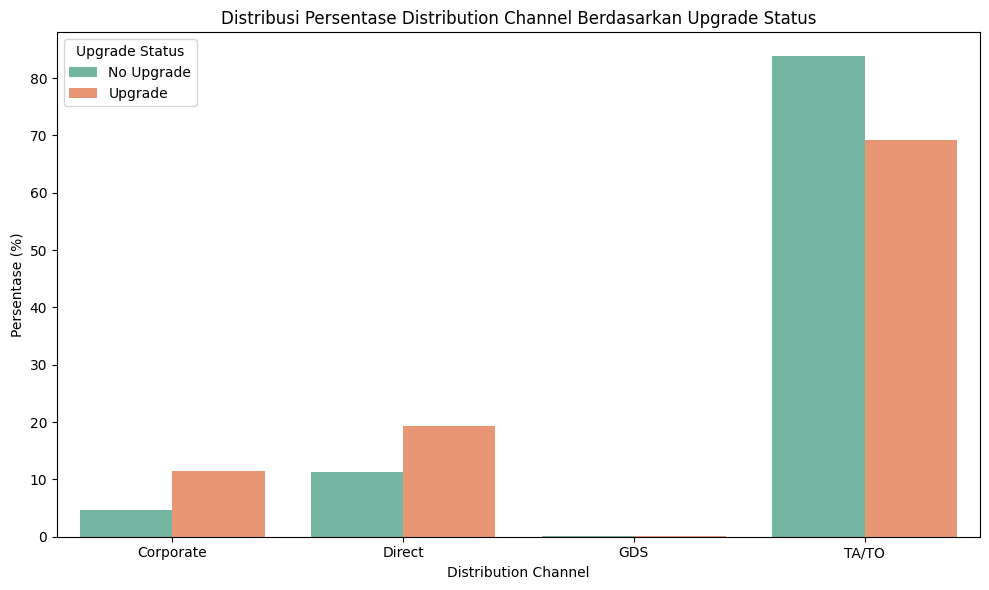

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=channel_upgrade,
    x='distribution_channel',
    y='percentage',
    hue='upgrade_status',
    palette='Set2'
)

plt.title('Distribusi Persentase Distribution Channel Berdasarkan Upgrade Status')
plt.ylabel('Persentase (%)')
plt.xlabel('Distribution Channel')
plt.legend(title='Upgrade Status')
plt.tight_layout()
plt.show()

Insight dari Jenis Reservasi terhadap Kemungkinan Upgrade Kamar


TA/TO (Travel Agent/Tour Operator):

- Sangat dominan dalam No Upgrade (83.80%), dan menurun pada Upgrade (69.17%).

- Artinya, meskipun TA/TO adalah saluran utama reservasi, peluang upgrade melalui channel ini justru lebih kecil dibanding channel lainnya.

Direct:

- Naik dari 11.31% (No Upgrade) menjadi 19.23% (Upgrade).

- Ini menunjukkan bahwa reservasi langsung memiliki peluang upgrade yang lebih tinggi, mungkin karena fleksibilitas lebih besar dalam pengelolaan kamar oleh pihak hotel.

Corporate:

- Meningkat dari 4.68% (No Upgrade) ke 11.55% (Upgrade).

- Seperti Direct, channel Corporate juga memiliki kemungkinan upgrade yang lebih tinggi, kemungkinan karena adanya hubungan bisnis atau paket layanan tertentu.

GDS (Global Distribution System):

- Turun dari 0.20% ke 0.05%, dan secara keseluruhan kontribusinya sangat kecil.

- Channel ini sangat jarang mendapat upgrade dan tidak signifikan.

**Jenis reservasi yang memiliki kemungkinan terbesar untuk mendapatkan upgrade kamar adalah Direct dan Corporate, karena persentasenya meningkat signifikan di kategori Upgrade. Sebaliknya, meskipun TA/TO paling banyak digunakan, peluangnya untuk upgrade justru lebih kecil.**

## Apakah durasi menginap di weekdays dan weekend akan mempengaruhi kemungkinan upgrade kamar?

In [ ]:
# Statistik deskriptif berdasarkan status upgrade
df_filtered.groupby('upgrade_status')[['stays_in_week_nights', 'stays_in_weekend_nights']].describe()

stays_in_week_nights                                          \
                              count      mean       std  min  25%  50%  75%   
upgrade_status                                                                
No Upgrade                  41623.0  2.546765  1.951521  0.0  1.0  2.0  3.0   
Upgrade                      5456.0  2.010997  1.935975  0.0  1.0  2.0  3.0   

                     stays_in_weekend_nights                                \
                 max                   count      mean       std  min  25%   
upgrade_status                                                               
No Upgrade      50.0                 41623.0  0.949427  1.016284  0.0  0.0   
Upgrade         35.0                  5456.0  0.699780  0.969587  0.0  0.0   

                                
                50%  75%   max  
upgrade_status                  
No Upgrade      1.0  2.0  19.0  
Upgrade         0.0  1.0  14.0

/tmp/ipython-input-62-743419755.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='upgrade_status', y='stays_in_week_nights', palette='Set2')
/tmp/ipython-input-62-743419755.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='upgrade_status', y='stays_in_weekend_nights', palette='Set2')


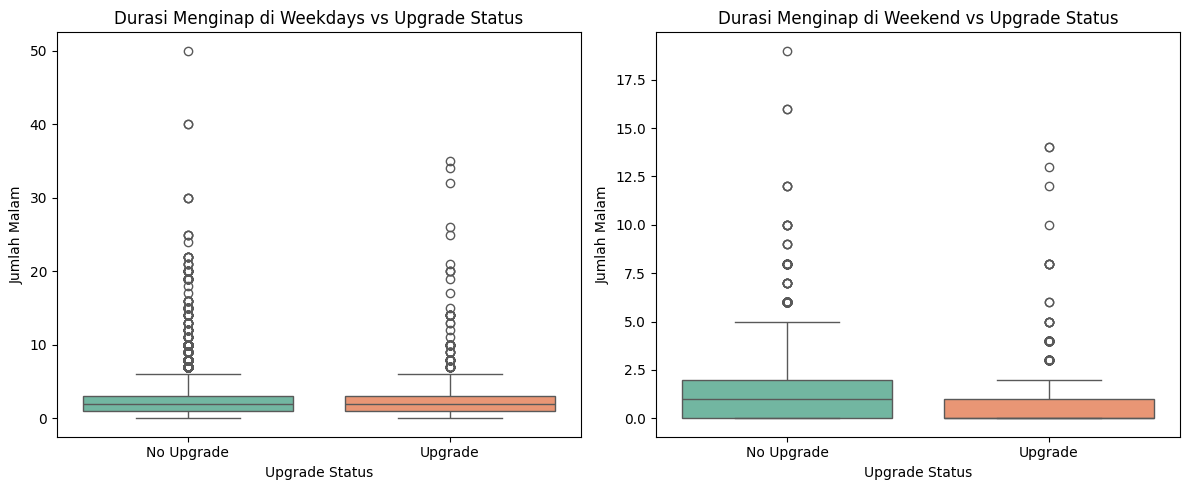

In [ ]:
plt.figure(figsize=(12,5))

# Weekday stay
plt.subplot(1, 2, 1)
sns.boxplot(data=df_filtered, x='upgrade_status', y='stays_in_week_nights', palette='Set2')
plt.title('Durasi Menginap di Weekdays vs Upgrade Status')
plt.ylabel('Jumlah Malam')
plt.xlabel('Upgrade Status')

# Weekend stay
plt.subplot(1, 2, 2)
sns.boxplot(data=df_filtered, x='upgrade_status', y='stays_in_weekend_nights', palette='Set2')
plt.title('Durasi Menginap di Weekend vs Upgrade Status')
plt.ylabel('Jumlah Malam')
plt.xlabel('Upgrade Status')

plt.tight_layout()
plt.show()

Weekdays

- Rata-rata tamu yang tidak di-upgrade menginap lebih lama di weekdays dibanding yang di-upgrade (2.55 malam vs 2.01 malam).

- Nilai median sama, namun mean menunjukkan bahwa durasi weekdays yang lebih lama justru tidak berhubungan positif dengan upgrade kamar.

Weekend

- Rata-rata weekend stay juga lebih pendek untuk tamu yang mendapat upgrade (0.70 malam) dibanding yang tidak di-upgrade (0.95 malam).

- Median juga lebih rendah (0.0 untuk Upgrade vs 1.0 untuk No Upgrade), artinya mayoritas tamu yang di-upgrade justru tidak menginap di akhir pekan.

**Durasi menginap baik di weekdays maupun weekend cenderung lebih pendek pada tamu yang mendapatkan upgrade kamar. Hal ini menunjukkan bahwa semakin lama tamu menginap, justru peluang upgrade kamar bisa menurun, Jadi, durasi lama tidak serta-merta meningkatkan peluang upgrade.**

# Modeling

In [ ]:
# rencana kolom untuk modeling

kolom_model = ['lead_time', 'booking_category', 'distribution_channel', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults',
                     'children', 'babies', 'pax_segment', 'required_car_parking_spaces', 'total_of_special_requests', 'is_repeated_guest',
                     'customer_type', 'upgrade_status']

In [ ]:
# ambil hanya yang tidak cancel dari df_filtered

df_noncancel = df_filtered[df_filtered['is_canceled'] == 0]

In [ ]:
# bentuk df_model berdasarkan kolom model

df_model = df_noncancel[kolom_model]

In [ ]:
# label encode upgrade_status

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_model['upgrade_status'] = le.fit_transform(df_model['upgrade_status'])

/tmp/ipython-input-66-2935240066.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['upgrade_status'] = le.fit_transform(df_model['upgrade_status'])


In [ ]:
# Lakukan mean encoding pada customer_type dan upgrade_status
target_col = 'upgrade_status'  # Ganti dengan nama kolom target kamu, misalnya 'is_canceled' atau lainnya

# Kolom yang ingin di-mean encode
mean_encode_cols = ['booking_category', 'distribution_channel', 'pax_segment', 'customer_type']

# Dictionary untuk menyimpan nilai mean tiap kategori
mean_encoding_maps = {}

for col in mean_encode_cols:
    # Hitung rata-rata target untuk setiap kategori
    encoding_map = df_model.groupby(col)[target_col].mean().to_dict()

    # Simpan untuk referensi
    mean_encoding_maps[col] = encoding_map

    # Ganti nilai kategori dengan nilai rata-rata target-nya
    df_model[col + '_mean_encoded'] = df_model[col].map(encoding_map)

# Tampilkan hasil mapping
for col, mapping in mean_encoding_maps.items():
    print(f"📌 Mean Encoding untuk kolom '{col}':")
    for k, v in mapping.items():
        print(f"  {k} → {v:.4f}")
    print()

📌 Mean Encoding untuk kolom 'booking_category':
  early_booking → 0.1353
  last_minute_booking → 0.2903
  normal_booking → 0.1949

📌 Mean Encoding untuk kolom 'distribution_channel':
  Corporate → 0.2964
  Direct → 0.2084
  GDS → 0.0411
  TA/TO → 0.1546

📌 Mean Encoding untuk kolom 'pax_segment':
  Family → 0.2055
  Group → 0.0000
  Solo/Couple → 0.1676
  Unaccompanied Children → 0.1905

📌 Mean Encoding untuk kolom 'customer_type':
  Contract → 0.1451
  Group → 0.2443
  Transient → 0.1719
  Transient-Party → 0.1741



/tmp/ipython-input-67-3646623497.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col + '_mean_encoded'] = df_model[col].map(encoding_map)
/tmp/ipython-input-67-3646623497.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col + '_mean_encoded'] = df_model[col].map(encoding_map)
/tmp/ipython-input-67-3646623497.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

In [ ]:
# save encoder

import joblib

# Simpan encoder ke file
joblib.dump(mean_encoding_maps, '/content/drive/MyDrive/Simulasi/mean_encoding_maps.pkl')

['/content/drive/MyDrive/Simulasi/mean_encoding_maps.pkl']

In [ ]:
df_model.head()

,lead_time,booking_category,distribution_channel,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,pax_segment,required_car_parking_spaces,total_of_special_requests,is_repeated_guest,customer_type,upgrade_status,booking_category_mean_encoded,distribution_channel_mean_encoded,pax_segment_mean_encoded,customer_type_mean_encoded
1,52,early_booking,TA/TO,0,2,3,0,0,Family,0,1,0,Transient,1,0.135319,0.154636,0.205491,0.171949
4,83,early_booking,TA/TO,2,5,2,0,0,Solo/Couple,0,0,0,Transient,0,0.135319,0.154636,0.167573,0.171949
5,6,normal_booking,TA/TO,0,1,1,0,0,Solo/Couple,0,0,0,Transient,1,0.194882,0.154636,0.167573,0.171949
6,165,early_booking,TA/TO,1,0,2,0,0,Solo/Couple,0,1,0,Transient,1,0.135319,0.154636,0.167573,0.171949
7,1,last_minute_booking,TA/TO,0,3,2,2,0,Family,0,0,0,Transient,0,0.290323,0.154636,0.205491,0.171949


In [ ]:
# save df_model

df_model.to_csv('/content/drive/MyDrive/Simulasi/df_model.csv', index=False)

In [ ]:
df_model_encode = df_model.drop(['booking_category', 'distribution_channel', 'pax_segment', 'customer_type'], axis=1)

In [ ]:
# bentuk x dan y dengan y adalah upgrade_status

X = df_model_encode.drop('upgrade_status', axis=1)
y = df_model_encode['upgrade_status']

In [ ]:
# split dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.head()

In [ ]:
# smote data train

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
# simpan masing-masing hasil smote dan split datatest di gdrive

X_train_resampled.to_csv('/content/drive/MyDrive/Simulasi/X_train_resampled.csv', index=False)
y_train_resampled.to_csv('/content/drive/MyDrive/Simulasi/y_train_resampled.csv', index=False)
X_test.to_csv('/content/drive/MyDrive/Simulasi/X_test.csv', index=False)
y_test.to_csv('/content/drive/MyDrive/Simulasi/y_test.csv', index=False)

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
# Daftar model yang akan dievaluasi

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=4, use_label_encoder=False, eval_metric='logloss', tree_method='hist', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
}

# Inisialisasi untuk menyimpan hasil evaluasi
results = []

# Ambil label positif dari y_train untuk dipakai secara dinamis
positive_label = y_train_resampled.unique()[1]  # Ambil label positif secara otomatis

# Proses pelatihan dan evaluasi untuk semua model
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = model.score(X_test, y_test)
    precision = precision_score(y_test, y_pred, pos_label=positive_label)
    recall = recall_score(y_test, y_pred, pos_label=positive_label)
    f1 = f1_score(y_test, y_pred, pos_label=positive_label)
    roc_auc = roc_auc_score((y_test == positive_label).astype(int), y_proba)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

    # Tampilkan classification report
    print(f"\n📋 Classification Report - {name}")
    print(classification_report(y_test, y_pred))

# Hasil evaluasi keseluruhan
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-Score', ascending=False)
print("\n📊 Evaluation Summary:")
print(results_df)

In [ ]:
# simpan model awal di gdrive

import joblib

# Simpan semua model ke satu file
joblib.dump(models, '/content/drive/MyDrive/Simulasi/model_awal.pkl')

| **Model**                     | **Insight Lengkap**                                                                                                                                                                                                                                                                                                                                                                                  |
| ----------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **K-Nearest Neighbors (KNN)** | - Memiliki akurasi tertinggi (**72.18%**), namun metrik lain justru rendah.<br>- **Recall hanya 35.13%**, artinya model ini gagal menangkap sebagian besar kelas positif.<br>- **F1-Score hanya 29.89%**, menunjukkan ketidakseimbangan antara precision dan recall.<br>- Kurang cocok digunakan jika tujuan utama adalah mendeteksi sebanyak mungkin kejadian penting (misalnya churn, fraud, dll). |
| **Random Forest**             | - Memberikan performa paling seimbang di semua metrik.<br>- **Recall tertinggi (54.79%)**, artinya lebih banyak kasus positif yang berhasil dikenali.<br>- **ROC-AUC tertinggi (0.6629)**, menunjukkan kemampuan klasifikasi yang cukup baik secara keseluruhan.<br>- Cocok digunakan sebagai model utama jika ingin hasil yang stabil dan andal.                                                    |
| **Gradient Boosting**         | - Performa sangat mirip dengan Random Forest, hanya sedikit lebih rendah.<br>- **Recall 54.69%**, dan ROC-AUC 0.6574.<br>- F1-Score juga seimbang, menunjukkan model ini bisa menjadi alternatif kuat.<br>- Dapat dipilih jika ingin model boosting dengan hasil mendekati Random Forest.                                                                                                            |
| **XGBoost**                   | - Performa sedang, tidak terlalu menonjol.<br>- **Recall 51.99%**, sedikit di bawah Random Forest dan Gradient Boosting.<br>- F1-Score lebih rendah dari keduanya (**34.58%**).<br>- Perlu tuning parameter lebih lanjut jika ingin hasil optimal.                                                                                                                                                   |
| **Logistic Regression**       | - Performa paling rendah di hampir semua metrik.<br>- **Akurasi hanya 62.88%**, dan F1-score juga rendah (**32.03%**).<br>- Walaupun recall-nya 51.79%, precision-nya rendah, sehingga menghasilkan banyak false positive.<br>- Bisa dijadikan baseline model, tapi kurang ideal untuk digunakan sebagai model akhir.                                                                                |


Random Forest merupakan model terbaik karena memberikan performa paling seimbang dengan recall dan ROC-AUC tertinggi. Gradient Boosting menjadi alternatif kuat dengan hasil yang hampir setara. XGBoost memiliki performa sedang dan masih perlu tuning untuk hasil optimal. KNN kurang cocok meskipun akurasinya tinggi karena recall dan F1-score-nya rendah. Logistic Regression memiliki performa terendah dan hanya layak dijadikan baseline.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, recall_score

# Inisialisasi model
rf = RandomForestClassifier(random_state=42)

# Ruang parameter
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced']
}

# Scorer khusus recall
recall_scorer = make_scorer(recall_score)

# Randomized Search
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring=recall_scorer,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_resampled, y_train_resampled)

# Tampilkan hasil terbaik
print("Best Parameters:", random_search.best_params_)
print("Best Recall Score:", random_search.best_score_)

In [ ]:
# simpan model di gdrive

import joblib

# Simpan semua model ke satu file
joblib.dump(random_search, '/content/drive/MyDrive/Simulasi/model_terbaik.pkl')

In [ ]:
# terapkan model yang sudah di hyperparameter tunning pada datatest

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score

# Classification report
print("📋 Classification Report - Tuned Random Forest")
print(classification_report(y_test, y_pred))

# Metrik individu
print("Accuracy:", best_model.score(X_test, y_test))
print("Precision:", precision_score(y_test, y_pred))  # default pos_label=1
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Perbandingan Sebelumnya vs Setelah Tuning (Random Forest)

| **Metrik**          | **Sebelum (Train/Validasi)** | **Sesudah (Test)** | **Perubahan**                      |
| ------------------- | ---------------------------- | ------------------ | ---------------------------------- |
| Accuracy            | 66.82%                       | **69.84%**         | 🔼 Meningkat, model lebih presisi  |
| Precision (class 1) | 26.58%                       | **27.38%**         | 🔼 Sedikit membaik                 |
| Recall (class 1)    | 54.79%                       | **47.60%**         | 🔽 Menurun, tapi masih cukup baik  |
| F1-Score (class 1)  | 35.80%                       | **34.76%**         | ⬇️ Sedikit menurun, tapi konsisten |
| ROC-AUC             | 0.6629                       | **0.6618**         | ⬌ Stabil (hanya sedikit berbeda)   |


Model Random Forest yang telah dituning menunjukkan performa yang stabil saat diuji pada data test, dengan akurasi meningkat menjadi 69.84% dan ROC-AUC tetap konsisten di sekitar 0.66. Recall kelas positif tetap cukup baik (47.6%), meskipun sedikit menurun dari sebelumnya, sementara precision mengalami sedikit peningkatan. F1-score juga masih seimbang, menandakan model mampu menjaga kinerja meski data tidak seimbang. Secara keseluruhan, model berhasil melakukan generalisasi dengan baik tanpa overfitting.

In [ ]:
#tentukan feature importance

model_terbaik_awal = models['Random Forest']

# Ambil feature importances dari model
feature_importances_model_standart = pd.Series(model_terbaik_awal.feature_importances_, index=X_train_resampled.columns)

# Urutkan dan tampilkan bar chart
feature_importances_model_standart.sort_values(ascending=True).plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
# Ambil feature importances dari model yang sudah di tuning
feature_importances = pd.Series(best_model.feature_importances_, index=X_train_resampled.columns)

# Urutkan dan tampilkan bar chart
feature_importances.sort_values(ascending=True).plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt

# Ambil sampel kecil dari data train yang sudah di-smote
sampled_X_awal = X_train_resampled.sample(300, random_state=42)  # ambil 300 baris saja

# Inisialisasi explainer dengan TreeExplainer (jauh lebih cepat)
explainer_awal = shap.TreeExplainer(model_terbaik_awal)

# Hitung shap values untuk sampel saja
shap_values_awal = explainer_awal.shap_values(sampled_X_awal)

# Tampilkan summary plot
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values_awal, sampled_X_awal, plot_type="dot", max_display=30)
plt.tight_layout()
plt.show()  # [1] untuk kelas positif

In [ ]:
import shap
import matplotlib.pyplot as plt

# Ambil sampel kecil dari data train yang sudah di-smote
sampled_X = X_train_resampled.sample(300, random_state=42)  # ambil 300 baris saja

# Inisialisasi explainer dengan TreeExplainer (jauh lebih cepat)
explainer = shap.TreeExplainer(best_model)

# Hitung shap values untuk sampel saja
shap_values = explainer.shap_values(sampled_X)

# Tampilkan summary plot
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, sampled_X, plot_type="bar")
plt.tight_layout()
plt.show()  # [1] untuk kelas positif

| **Fitur**                                                    | **Pentingnya**  | **Insight**                                                          |
| ------------------------------------------------------------ | --------------- | -------------------------------------------------------------------- |
| `lead_time`                                                  | Sangat tinggi   | Fitur paling dominan, kontribusi hampir 50% terhadap prediksi model. |
| `stays_in_week_nights`                                       | Tinggi          | Durasi tinggal di hari kerja berpengaruh besar.                      |
| `stays_in_weekend_nights`                                    | Cukup tinggi    | Durasi tinggal di akhir pekan juga relevan dalam prediksi.           |
| `total_of_special_requests`                                  | Menengah        | Permintaan khusus ikut mempengaruhi prediksi.                        |
| `distribution_channel`                                       | Menengah        | Saluran pemesanan berdampak terhadap output model.                   |
| `adults`, `customer_type`, `pax_segment`                     | Rendah-menengah | Memberikan kontribusi, tapi tidak sebesar fitur utama.               |
| `children`, `booking_category`                               | Rendah          | Kurang berpengaruh terhadap keputusan model.                         |
| `required_car_parking_spaces`, `is_repeated_guest`, `babies` | Sangat rendah   | Hampir tidak digunakan model untuk pengambilan keputusan.            |


Model Random Forest sangat bergantung pada fitur lead_time, yang memiliki kontribusi paling besar dibanding fitur lainnya. Fitur durasi menginap (stays_in_week_nights dan stays_in_weekend_nights) serta permintaan khusus juga cukup berpengaruh. Sementara itu, fitur seperti babies, is_repeated_guest, dan car_parking_spaces memiliki pengaruh sangat rendah terhadap prediksi model.

# Insight

- Upgrade lebih sering terjadi pada last-minute (20.56%) dan normal booking (33.56%), sedangkan early booking justru lebih sering tidak di-upgrade (69.87%).

- Family memiliki peluang upgrade yang lebih tinggi (14.41%) dibanding sebelumnya (12.03%), sementara Group tidak pernah mendapat upgrade.

- Direct dan Corporate lebih sering mendapat upgrade dibanding TA/TO, meskipun TA/TO mendominasi jumlah reservasi.

- Rata-rata durasi menginap lebih pendek pada tamu yang di-upgrade, baik di weekdays (2.01 malam) maupun weekend (0.70 malam), dibanding yang tidak di-upgrade.

# Recommendation

Rekomendasi Strategis: Meningkatkan Terjadinya Upgrade Kamar Berbayar & Meningkatkan ADR

1. Tawarkan Upgrade Berbayar Khusus untuk Last-Minute dan Normal Booking

  Berdasarkan data, kategori ini lebih cenderung di-upgrade, jadi arahkan perilaku itu ke penawaran berbayar.

  Contoh strategi:

  “Tamu yang booking < 5 hari sebelum check-in mendapat penawaran spesial upgrade kamar dengan diskon 30% saat check-in.”

  Mereka sudah berada dalam posisi fleksibel dan cenderung lebih impulsif saat memesan.

2. Optimalkan Channel Direct dan Corporate dengan Penawaran Bundling

  Karena Direct dan Corporate lebih berpeluang di-upgrade, buatkan paket upgrade seperti:

  “Upgrade ke kamar deluxe hanya +RpXXX jika reservasi melalui website hotel!”
  atau
  “Perusahaan partner mendapatkan fixed rate + upgrade kamar untuk tamu VIP.”

  Ini mengalihkan biaya upgrade ke tamu yang lebih berpotensi membayar, bukan diskon massal.

3. Kampanye “Short Weekend, Big Comfort” untuk Tamu Menginap 1 Malam

  Berdasarkan data, tamu yang di-upgrade sering hanya menginap 1 malam → manfaatkan ini untuk menawarkan kenyamanan maksimal:

  “Menginap cuma 1 malam? Nikmati kamar superior kami dengan tambahan hanya RpXXX untuk pengalaman yang lebih nyaman.”

4. Prioritaskan Penawaran Upgrade untuk Segmen Family dan Solo/Couple dengan Alasan Emosional atau Kenyamanan

  Gunakan data pax_segment:

  Family → “Nikmati ruang ekstra untuk keluarga Anda hanya +RpXXX.”

  Solo/Couple → “Ciptakan momen lebih spesial di kamar premium hanya +RpXXX/malam.”